# FPL Decision Support System — Modelling Notebook
**Thesis Project** | PyCaret AutoML vs AutoKeras Deep Learning

---
### ⚠️ Before running anything:
1. Go to `Runtime` → `Change runtime type` → select **T4 GPU** and runtime version **2025.07** → Save
2. Follow the instructions carefully — there is a required runtime restart between sections

### Pipeline
- **Section 1** — Mount Drive + Install PyCaret → ⚠️ Restart Runtime
- **Section 2** — Load & Prepare Data
- **Section 3** — PyCaret AutoML Benchmarking
- **Section 4** — Install AutoKeras + Deep Learning
- **Section 5** — Model Comparison
- **Section 6** — Prediction Intervals (Ensemble)
- **Section 7** — PuLP Squad Optimisation
- **Section 8** — Save All Outputs

normalizar los feautures
porcentaje train/test

---
## Section 1 — Setup
### Step 1a: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


### Step 1b: Install PyCaret
⚠️ **After this cell finishes — restart the runtime before continuing.**

`Runtime` → `Restart runtime` → then continue from Section 2.

In [13]:
!pip install pycaret==3.3.2 scikit-learn==1.4.2 -q
print('PyCaret installed. RESTART THE RUNTIME NOW: Runtime → Restart runtime')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## Section 2 — Load & Prepare Data
Run all cells in this section after restarting the runtime.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/fpl_thesis'
MODEL_DIR = '/content/drive/MyDrive/fpl_thesis/models/nb1_regression_all'
os.makedirs(MODEL_DIR, exist_ok=True)

DATA_PATH = f'{BASE}/data/processed/nb1_data/featured_training_set.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Mounted at /content/drive
Loaded: 52608 rows, 70 columns


,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,...,pts_per_million,price_change,opp_avg_goals_scored,opp_avg_goals_conceded,played_60_plus,blanked,games_played,gi_rate,rolling_yellows_3,red_card_flag
0,Aaron Hickey,DEF,Brentford,2.0,0,0,7,0,10.8,104,...,0.000000,0.0,NaN,NaN,1,1,1,0.0,NaN,0
1,Aaron Hickey,DEF,Brentford,2.5,0,0,15,1,1.5,104,...,1.111111,0.0,2.0,20.0,1,0,2,0.0,1.000000,0
2,Aaron Hickey,DEF,Brentford,2.3,0,0,13,0,3.8,104,...,0.444444,0.0,2.5,10.0,1,0,3,0.0,1.000000,0
3,Aaron Hickey,DEF,Brentford,2.0,0,0,19,0,1.2,104,...,0.222222,0.0,2.0,10.0,1,1,4,0.0,0.666667,0
4,Aaron Hickey,DEF,Brentford,0.8,0,0,6,0,1.3,104,...,0.222222,0.0,2.0,12.0,1,1,5,0.0,0.333333,0


In [2]:
# Create TARGET: next GW points for each player
df = df.sort_values(['element', 'season', 'GW']).reset_index(drop=True)
df['target'] = df.groupby(['element', 'season'])['total_points'].shift(-1)
df = df.dropna(subset=['target']).reset_index(drop=True)
print(f'After creating target: {df.shape[0]} rows')

After creating target: 50932 rows


In [3]:
# Keep metadata for later
META_COLS = ['name', 'team', 'position', 'element', 'season', 'GW', 'total_points']
test_meta_cols = ['name', 'team', 'position', 'element', 'GW', 'value']

DROP_COLS = [
    'name', 'team', 'season', 'GW', 'kickoff_time',
    'total_points', 'element', 'fixture', 'modified',
]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

# Encode position
if df['position'].dtype == object:
    df['position'] = df['position'].astype('category').cat.codes
if 'was_home' in df.columns:
    df['was_home'] = df['was_home'].astype(int)

model_df = df.drop(columns=DROP_COLS)
model_df['season'] = df['season'].values
model_df['GW']     = df['GW'].values
print(f'model_df shape: {model_df.shape}')

model_df shape: (50932, 64)


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pickle

# Walk-Forward Split: Train GW1-14 of 2526 + all 2324/2425 | Test GW15-29 of 2526
train_mask = (
    model_df['season'].isin([2324, 2425]) |
    ((model_df['season'] == 2526) & (model_df['GW'] < 15))
)
test_mask = (model_df['season'] == 2526) & (model_df['GW'] >= 15)

train_df = model_df[train_mask].copy()
test_df  = model_df[test_mask].copy()

# Keep test metadata
test_meta = df[test_mask][test_meta_cols].copy()

print(f'Train: {len(train_df)} rows ({len(train_df)/len(model_df)*100:.1f}%)')
print(f'Test:  {len(test_df)} rows ({len(test_df)/len(model_df)*100:.1f}%)')

# Combined sample weights: season × playing time × target value
def get_combined_weight(row):
    season_w = {2324: 0.5, 2425: 0.75, 2526: 1.0}.get(int(row['season']), 1.0)
    mins_col = 'rolling_mins_3' if 'rolling_mins_3' in row.index else None
    mins_ok  = (row[mins_col] >= 30) if mins_col else True
    if not mins_ok:
        return season_w * 0.3
    elif row['target'] <= 1:
        return season_w * 0.5
    elif row['target'] <= 5:
        return season_w * 1.0
    elif row['target'] <= 9:
        return season_w * 2.0
    else:
        return season_w * 3.0

sample_weights = train_df.apply(get_combined_weight, axis=1).values
print(f'Sample weights — mean: {sample_weights.mean():.3f}, max: {sample_weights.max():.1f}')

# Impute + StandardScaler
FEAT_COLS = [c for c in train_df.columns if c not in ['target', 'season', 'GW']]
X_train_raw = train_df[FEAT_COLS].values.astype(np.float32)
y_train     = train_df['target'].values.astype(np.float32)
X_test_raw  = test_df[FEAT_COLS].values.astype(np.float32)
y_test      = test_df['target'].values.astype(np.float32)

imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp  = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Keep imputed arrays for AutoKeras
X_train_imputed = X_train_imp
X_test_imputed  = X_test_imp

# Save scaler and imputer
with open(f'{MODEL_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(f'{MODEL_DIR}/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

# Naive baseline
from sklearn.metrics import mean_absolute_error, r2_score
naive_mae = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))
print(f'Naive baseline MAE: {naive_mae:.4f}')
print(f'X_train_scaled: {X_train_scaled.shape}')
print(f'X_test_scaled:  {X_test_scaled.shape}')
print('Scaler and imputer saved.')

Train: 39740 rows (78.0%)
Test:  11192 rows (22.0%)
Sample weights — mean: 0.431, max: 3.0
Naive baseline MAE: 1.6600
X_train_scaled: (39740, 61)
X_test_scaled:  (11192, 61)
Scaler and imputer saved.


In [5]:
# Build scaled DataFrames for PyCaret
train_pc = pd.DataFrame(X_train_scaled, columns=FEAT_COLS)
train_pc['target'] = y_train
test_pc  = pd.DataFrame(X_test_scaled,  columns=FEAT_COLS)
print(f'PyCaret train: {train_pc.shape}')
print(f'PyCaret test:  {test_pc.shape}')

PyCaret train: (39740, 62)
PyCaret test:  (11192, 61)


---
## Section 3 — PyCaret AutoML Benchmarking
PyCaret automatically trains and compares ~20 regression models using 5-fold cross-validation.
Sorted by MAE — most interpretable metric for FPL points prediction.

In [6]:
from pycaret.regression import *

pc_setup = setup(
    data            = train_pc,
    target          = 'target',
    session_id      = 42,
    fold            = 5,
    verbose         = True,
    use_gpu         = True,
    normalize       = False,   # already done with StandardScaler
    imputation_type = None,    # already done
    data_split_shuffle = False,
)
print('PyCaret setup complete.')

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that mee

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Regression
3,Original data shape,"(39740, 62)"
4,Transformed data shape,"(39740, 62)"
5,Transformed train set shape,"(27818, 62)"
6,Transformed test set shape,"(11922, 62)"
7,Numeric features,61
8,Preprocess,True
9,Imputation type,None


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that mee

In [7]:
best_models = compare_models(
    sort     = 'MAE',
    n_select = 3,
    exclude  = ['ransac', 'rf', 'et', 'ada', 'gbr'],
    verbose  = True
)
print(f'\nTop 3 models: {[type(m).__name__ for m in best_models]}')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,1.1960,6.1190,2.4683,0.1826,0.5537,0.5907,1.0480
lightgbm,Light Gradient Boosting Machine,1.3457,5.4909,2.3380,0.2668,0.5775,0.8182,2.2780
ridge,Ridge Regression,1.3699,5.4214,2.3242,0.2747,0.5816,0.8149,0.0360
br,Bayesian Ridge,1.3709,5.4202,2.3239,0.2749,0.5823,0.8094,0.0860
omp,Orthogonal Matching Pursuit,1.3842,5.4709,2.3349,0.2680,0.5882,0.8116,0.0340
xgboost,Extreme Gradient Boosting,1.4087,6.0146,2.4469,0.1968,0.6063,0.8784,0.5900
knn,K Neighbors Regressor,1.4170,6.3852,2.5228,0.1452,0.6331,0.9028,0.3120
lr,Linear Regression,1.4448,5.7222,2.3906,0.2277,0.6114,0.7922,0.3620
en,Elastic Net,1.5244,5.9641,2.4372,0.2028,0.6663,0.5900,0.0740
llar,Lasso Least Angle Regression,1.6761,6.7760,2.5977,0.0945,0.7519,0.5238,0.0480


Processing:   0%|          | 0/63 [00:00<?, ?it/s]

[2026-05-13 13:06:16.947] [CUML] [info] Unused keyword parameter: n_jobs during cuML estimator initialization



Top 3 models: ['HuberRegressor', 'LGBMRegressor', 'Ridge']


In [8]:
import pickle
with open(f'{MODEL_DIR}/best_models.pkl', 'wb') as f:
    pickle.dump(best_models, f)
print('Top 3 models saved.')

Top 3 models saved.


In [9]:
tuned_model = tune_model(best_models[0], optimize='MAE', n_iter=20)
print(f'Best model after tuning: {type(tuned_model).__name__}')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.2918,6.9189,2.6304,0.1634,0.5727,0.5917
1,1.0121,4.9423,2.2231,0.1992,0.5201,0.5826
2,1.1972,5.9441,2.4380,0.1637,0.5612,0.6067
3,1.3416,7.2059,2.6844,0.1600,0.5944,0.6094
4,1.1069,5.7973,2.4078,0.1991,0.5348,0.5901
Mean,1.1899,6.1617,2.4767,0.1771,0.5566,0.5961
Std,0.1199,0.8162,0.1657,0.0181,0.0265,0.0103


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best model after tuning: HuberRegressor


In [14]:
from sklearn.metrics import mean_absolute_error, r2_score

# Don't finalize — just predict on test set directly
pycaret_preds = predict_model(tuned_model, data=test_pc)
pc_pred_values = np.clip(pycaret_preds['prediction_label'].values, 0, None)

mae_pc = mean_absolute_error(y_test, pc_pred_values)
r2_pc  = r2_score(y_test, pc_pred_values)

print(f'PyCaret Test MAE : {mae_pc:.4f}')
print(f'PyCaret Test R²  : {r2_pc:.4f}')
print(f'Naive Baseline   : {naive_mae:.4f}')
print(f'Improvement      : {((naive_mae-mae_pc)/naive_mae)*100:.1f}%')

NameError: name 'predict_model' is not defined

In [13]:
import json
save_model(tuned_model, f'{MODEL_DIR}/pycaret_best_model')
pycaret_preds_raw = pc_pred_values
pycaret_preds['prediction_label'] = pc_pred_values
pycaret_preds.to_csv(f'{MODEL_DIR}/pycaret_preds.csv', index=False)

results = {
    'model': type(tuned_model).__name__,
    'test_mae': float(round(mae_pc, 4)),
    'test_r2': float(round(r2_pc, 4)),
    'naive_mae': float(round(naive_mae, 4))
}
with open(f'{MODEL_DIR}/pycaret_results.json', 'w') as f:
    json.dump(results, f)
print('PyCaret model and results saved.')
print('→ Restart runtime for AutoKeras session')

Transformation Pipeline and Model Successfully Saved
PyCaret model and results saved.
→ Restart runtime for AutoKeras session


In [7]:
import pickle
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

MODEL_DIR = '/content/drive/MyDrive/fpl_thesis/models/nb1_regression_all'

# Load saved model
with open(f'{MODEL_DIR}/pycaret_best_model.pkl', 'rb') as f:
    tuned_model = pickle.load(f)

# Load saved results
import json
with open(f'{MODEL_DIR}/pycaret_results.json') as f:
    results = json.load(f)

naive_mae = results['naive_mae']
mae_pc    = results['test_mae']
r2_pc     = results['test_r2']

print(f'PyCaret Test MAE : {mae_pc:.4f}')
print(f'PyCaret Test R²  : {r2_pc:.4f}')
print(f'Naive Baseline   : {naive_mae:.4f}')
print(f'Improvement      : {((naive_mae-mae_pc)/naive_mae)*100:.1f}%')

PyCaret Test MAE : 0.8344
PyCaret Test R²  : 0.2479
Naive Baseline   : 1.6600
Improvement      : 49.7%


---
## Section 4 — AutoKeras Deep Learning
AutoKeras automatically searches for the best neural network architecture.

No runtime restart needed — install AutoKeras directly.

In [10]:
!pip install autokeras==3.0.0 tensorflow==2.18.0 -q
print('AutoKeras installed.')

AutoKeras installed.


In [11]:
import autokeras as ak
import tensorflow as tf

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.18.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [20]:
import autokeras as ak
import tensorflow as tf

ak_model = ak.StructuredDataRegressor(
    max_trials   = 10,
    overwrite    = False,
    seed         = 42,
    directory    = f'{MODEL_DIR}/ak_trials',
    project_name = 'nb1_autokeras'
)

ak_model.fit(
    X_train_imputed,
    y_train,
    epochs           = 35,
    validation_split = 0.1,
    verbose          = 1
)

Reloading Tuner from /content/drive/MyDrive/fpl_thesis/models/nb1_regression_all/ak_trials/nb1_autokeras/tuner0.json
Epoch 1/35
1242/1242 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 5.5233 - mean_squared_error: 5.5233
Epoch 2/35
1242/1242 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.1007 - mean_squared_error: 5.1007
Epoch 3/35
1242/1242 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 4.9323 - mean_squared_error: 4.9323
Epoch 4/35
1242/1242 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.9611 - mean_squared_error: 4.9611
Epoch 5/35
1242/1242 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.8726 - mean_squared_error: 4.8726
Epoch 6/35
1242/1242 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.8224 - mean_squared_error: 4.8224
Epoch 7/35
1242/1242 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 4.7552 - mean_squared_error: 4.7552
Epoch 8/35
1242/1242 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.8966 - mean_squared_error: 4.8966
Epoch 9/35
1242/1242 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.6489 - mean_squared_error: 4.6489
E

In [22]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

ak_preds_raw = ak_model.predict(X_test_imputed).flatten()
mae_ak = mean_absolute_error(y_test, ak_preds_raw)
r2_ak  = r2_score(y_test, ak_preds_raw)

print(f'AutoKeras Test MAE : {mae_ak:.4f}')
print(f'AutoKeras Test R²  : {r2_ak:.4f}')

best_ak_model = ak_model.export_model()
best_ak_model.save(f'{MODEL_DIR}/autokeras_best_model.keras')

import json
ak_results = {
    'model': 'AutoKeras Neural Network',
    'test_mae': round(mae_ak),
    'test_r2': round(r2_ak)
}
with open(f'{MODEL_DIR}/autokeras_results.json', 'w') as f:
    json.dump(ak_results, f)
print('AutoKeras model and results saved.')
print(f'MAE: {float(mae_ak):.4f}, R²: {float(r2_ak):.4f}')

350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
AutoKeras Test MAE : 1.0761
AutoKeras Test R²  : 0.3377
AutoKeras model and results saved.
MAE: 1.0761, R²: 0.3377


In [14]:
import tensorflow as tf
import autokeras as ak
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
import json

MODEL_DIR = '/content/drive/MyDrive/fpl_thesis/models/nb1_regression_all'

best_ak_model = tf.keras.models.load_model(
    f'{MODEL_DIR}/autokeras_best_model.keras',
    custom_objects=ak.CUSTOM_OBJECTS
)

ak_preds_raw = best_ak_model.predict(X_test_imputed).flatten()
mae_ak = mean_absolute_error(y_test, ak_preds_raw)
r2_ak  = r2_score(y_test, ak_preds_raw)

print(f'AutoKeras Test MAE : {mae_ak:.4f}')
print(f'AutoKeras Test R²  : {r2_ak:.4f}')

ak_results = {
    'model': 'AutoKeras Neural Network',
    'test_mae': float(round(mae_ak, 4)),
    'test_r2': float(round(r2_ak, 4))
}
with open(f'{MODEL_DIR}/autokeras_results.json', 'w') as f:
    json.dump(ak_results, f)
print('AutoKeras results saved.')

350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
AutoKeras Test MAE : 1.0320
AutoKeras Test R²  : -0.0285
AutoKeras results saved.


---
## Section 5 — Model Comparison
Side-by-side comparison of PyCaret (Huber Regressor) vs AutoKeras vs Naive Baseline.

===== NB1 Model Comparison =====
                     Model      MAE       R2
  PyCaret (HuberRegressor) 0.834400 0.247900
AutoKeras (Neural Network) 1.076118 0.337652
            Naive Baseline 1.660000      NaN


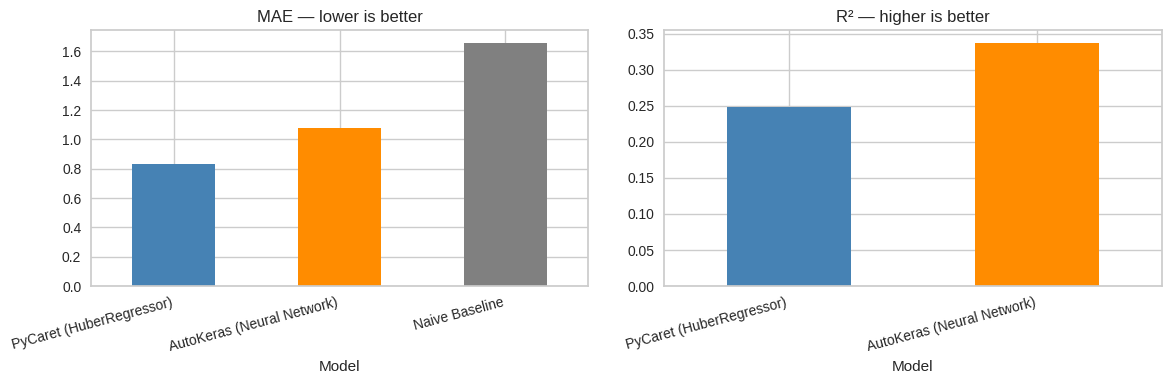

Comparison chart saved.


In [23]:
import matplotlib.pyplot as plt
import pandas as pd

comparison = pd.DataFrame({
    'Model' : ['PyCaret (HuberRegressor)', 'AutoKeras (Neural Network)', 'Naive Baseline'],
    'MAE'   : [mae_pc, mae_ak, naive_mae],
    'R2'    : [r2_pc,  r2_ak,  None],
})

print('===== NB1 Model Comparison =====')
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['steelblue', 'darkorange', 'gray']

comparison.plot(kind='bar', x='Model', y='MAE', ax=axes[0], color=colors, legend=False)
axes[0].set_title('MAE — lower is better')
axes[0].set_xticklabels(comparison['Model'], rotation=15, ha='right')

comparison.dropna().plot(kind='bar', x='Model', y='R2', ax=axes[1], color=colors[:2], legend=False)
axes[1].set_title('R² — higher is better')
axes[1].set_xticklabels(comparison.dropna()['Model'], rotation=15, ha='right')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/model_comparison.png', dpi=150)
plt.show()
print('Comparison chart saved.')

---
## Section 6 — Generate Player Predictions
Using the best model (winner by MAE) to generate predictions for all players.

In [24]:
# Run if session disconnected — reload predictions
import pandas as pd
import numpy as np

pc_df = pd.read_csv(f'{MODEL_DIR}/pycaret_preds.csv')
pycaret_preds_raw = pc_df['prediction_label'].values
print(f'PyCaret predictions loaded: {len(pycaret_preds_raw)} rows')

PyCaret predictions loaded: 11192 rows


In [25]:
# Run if session disconnected — reload AutoKeras
import autokeras as ak
import tensorflow as tf

best_ak_model = tf.keras.models.load_model(
    f'{MODEL_DIR}/autokeras_best_model.keras',
    custom_objects=ak.CUSTOM_OBJECTS
)
ak_preds_raw = best_ak_model.predict(X_test_imputed).flatten()
print(f'AutoKeras predictions loaded: {len(ak_preds_raw)} rows')

350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
AutoKeras predictions loaded: 11192 rows


In [26]:
import numpy as np
import os

# Use PyCaret (Huber) predictions — winner on MAE
predictions_df = test_meta.copy().reset_index(drop=True)
predictions_df['predicted_pts_mid'] = np.round(np.clip(pycaret_preds_raw, 0, None), 2)
predictions_df['actual_pts']        = y_test

print(predictions_df[['name','team','position','GW','value','predicted_pts_mid','actual_pts']].head(10))

OUT_PATH = f'{MODEL_DIR}/predictions.csv'
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
predictions_df.to_csv(OUT_PATH, index=False)
print(f'Predictions saved. Shape: {predictions_df.shape}')

                name     team  position  GW  value  predicted_pts_mid  \
0  David Raya Martín  Arsenal         2  15    5.9               2.43   
1  David Raya Martín  Arsenal         2  16    6.0               2.35   
2  David Raya Martín  Arsenal         2  17    6.0               2.26   
3  David Raya Martín  Arsenal         2  18    6.0               2.35   
4  David Raya Martín  Arsenal         2  19    6.0               2.28   
5  David Raya Martín  Arsenal         2  20    6.0               2.11   
6  David Raya Martín  Arsenal         2  21    6.0               2.17   
7  David Raya Martín  Arsenal         2  22    5.9               2.29   
8  David Raya Martín  Arsenal         2  23    5.9               2.13   
9  David Raya Martín  Arsenal         2  24    5.9               2.56   

   actual_pts  
0         2.0  
1         7.0  
2         2.0  
3         2.0  
4         1.0  
5         6.0  
6         6.0  
7         1.0  
8         6.0  
9         7.0  
Predictions saved. S

In [27]:
premium = ['Salah', 'Haaland', 'Palmer', 'Mbeumo', 'van Dijk', 'Pickford']
for player in premium:
    result = predictions_df[predictions_df['name'].str.contains(player)]
    if len(result) > 0:
        print(result[['name', 'GW', 'predicted_pts_mid', 'actual_pts']].to_string())
        print()

               name  GW  predicted_pts_mid  actual_pts
5350  Mohamed Salah  15               0.77         7.0
5351  Mohamed Salah  16               2.80         0.0
5352  Mohamed Salah  17               0.73         0.0
5353  Mohamed Salah  18               0.68         0.0
5354  Mohamed Salah  19               0.71         0.0
5355  Mohamed Salah  20               0.63         0.0
5356  Mohamed Salah  21               0.63         0.0
5357  Mohamed Salah  22               0.56         5.0
5358  Mohamed Salah  23               3.02         5.0
5359  Mohamed Salah  24               2.44         2.0
5360  Mohamed Salah  25               2.78         6.0
5361  Mohamed Salah  26               2.98         3.0
5362  Mohamed Salah  27               2.29         2.0
5363  Mohamed Salah  28               2.78         9.0

                name  GW  predicted_pts_mid  actual_pts
6036  Erling Haaland  15               2.85        13.0
6037  Erling Haaland  16               3.55        16.0
6038  

---
### ✅ NB1 Pipeline Complete

**Key differences from NB2:**
- All columns used (raw stats + engineered features)
- Same combined sample weighting (season × minutes × target)
- Same StandardScaler normalization
- Same 85/15 walk-forward split

**Results saved to:** `models/nb1_regression_all/`